# 04 Model Training and Optimization

This notebook reviews the saved training outputs from the production pipeline. Run `python src/train_model.py` beforehand to regenerate the model artifact, evaluation tables, and figures.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
REPORTS_DIR = PROJECT_ROOT / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
import joblib
import pandas as pd

artifact = joblib.load(PROJECT_ROOT / 'models' / 'churn_model.pkl')
comparison_df = pd.read_csv(REPORTS_DIR / 'model_comparison.csv')
threshold_df = pd.read_csv(REPORTS_DIR / 'threshold_comparison.csv')
lift_df = pd.read_csv(REPORTS_DIR / 'lift_table.csv')
calibration_df = pd.read_csv(REPORTS_DIR / 'calibration_table.csv')
error_df = pd.read_csv(REPORTS_DIR / 'error_analysis.csv')
shap_df = pd.read_csv(REPORTS_DIR / 'shap_feature_importance.csv')
comparison_df

C:\Users\suhas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,model_name,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,XGBoost,0.727079,0.491987,0.820856,0.615230,0.841011,0.652591
1,Logistic Regression,0.724947,0.489292,0.794118,0.605505,0.835419,0.618824
2,Random Forest,0.771855,0.562945,0.633690,0.596226,0.829533,0.624805


## Model Strategy

- Logistic Regression provides an interpretable baseline.
- Random Forest captures non-linear interactions.
- XGBoost is tuned with `GridSearchCV` using ROC-AUC as the primary objective.
- Class imbalance is handled with `scale_pos_weight` and balanced class weighting.

In [2]:
print('Best model:', artifact['model_name'])
print('Best XGBoost params:', artifact['xgboost_best_params'])
print('Best CV ROC-AUC:', round(artifact['xgboost_best_cv_score'], 3))
print('Average precision:', round(artifact['average_precision'], 3))
print('Brier score:', round(artifact['brier_score'], 3))
print('Top-decile churn capture:', f"{artifact['top_decile_capture']:.1%}")

Best model: XGBoost
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 400, 'subsample': 0.8}
Best CV ROC-AUC: 0.848
Average precision: 0.653
Brier score: 0.17
Top-decile churn capture: 26.7%


In [3]:
comparison_df

,model_name,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,XGBoost,0.727079,0.491987,0.820856,0.615230,0.841011,0.652591
1,Logistic Regression,0.724947,0.489292,0.794118,0.605505,0.835419,0.618824
2,Random Forest,0.771855,0.562945,0.633690,0.596226,0.829533,0.624805


In [4]:
threshold_df

,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,0.5,0.727079,0.491987,0.820856,0.615230,0.841011,0.652591
1,0.4,0.683014,0.450685,0.879679,0.596014,0.841011,0.652591


In [5]:
lift_df

,decile,customer_count,churners,churn_rate,avg_predicted_probability,lift_vs_baseline,cumulative_churners,cumulative_capture_rate,cumulative_population_share
0,1,140,100,0.714286,0.853908,2.687166,100,0.267380,0.099502
1,2,141,87,0.617021,0.771701,2.321254,187,0.500000,0.199716
2,3,141,58,0.411348,0.685858,1.547503,245,0.655080,0.299929
3,4,140,50,0.357143,0.598467,1.343583,295,0.788770,0.399431
4,5,141,25,0.177305,0.490457,0.667027,320,0.855615,0.499645
5,6,141,30,0.212766,0.355132,0.800432,350,0.935829,0.599858
6,7,140,12,0.085714,0.239916,0.322460,362,0.967914,0.699360
7,8,141,10,0.070922,0.130445,0.266811,372,0.994652,0.799574
8,9,141,1,0.007092,0.069156,0.026681,373,0.997326,0.899787
9,10,141,1,0.007092,0.046151,0.026681,374,1.000000,1.000000


In [6]:
calibration_df

,mean_predicted_probability,observed_positive_rate
0,0.046151,0.007092
1,0.069156,0.007092
2,0.130056,0.071429
3,0.239526,0.085106
4,0.355132,0.212766
5,0.489974,0.171429
6,0.598180,0.361702
7,0.685586,0.407143
8,0.771063,0.617021
9,0.853624,0.716312


In [7]:
error_df.head(15)

,dimension,segment,customer_count,actual_churn_rate,avg_predicted_probability,false_negative_count,false_negative_rate,false_positive_count,false_positive_rate,expected_monthly_revenue_at_risk
0,Contract,Two year,327,0.024465,0.083638,8,1.000000,0,0.000000,2064.309367
1,Contract,One year,290,0.137931,0.262198,19,0.475000,51,0.204000,6161.749970
2,InternetService,No,312,0.076923,0.182436,10,0.416667,24,0.083333,1174.699559
3,TechSupport,No internet service,312,0.076923,0.182436,10,0.416667,24,0.083333,1174.699559
4,TechSupport,Yes,382,0.146597,0.291648,22,0.392857,89,0.273006,9086.311837
5,tenure_bucket,49+ months,435,0.082759,0.212241,12,0.333333,72,0.180451,8260.689252
6,PaymentMethod,Bank transfer (automatic),307,0.195440,0.287063,18,0.300000,54,0.218623,6742.814063
7,InternetService,DSL,482,0.188797,0.338225,25,0.274725,127,0.324808,8400.167230
8,tenure_bucket,25-48 months,315,0.215873,0.355137,18,0.264706,84,0.340081,8912.877725
9,monthly_charge_bucket,0-35,357,0.109244,0.228631,10,0.256410,43,0.135220,1871.551347


In [8]:
shap_df.head(15)

,feature,importance
0,Contract_Two year,0.598965
1,tenure,0.434243
2,InternetService_Fiber optic,0.331953
3,Contract_One year,0.201706
4,PaymentMethod_Electronic check,0.179359
5,InternetService_No,0.143329
6,MonthlyCharges,0.121833
7,OnlineSecurity_Yes,0.081199
8,TotalCharges,0.075788
9,PaperlessBilling_Yes,0.069199


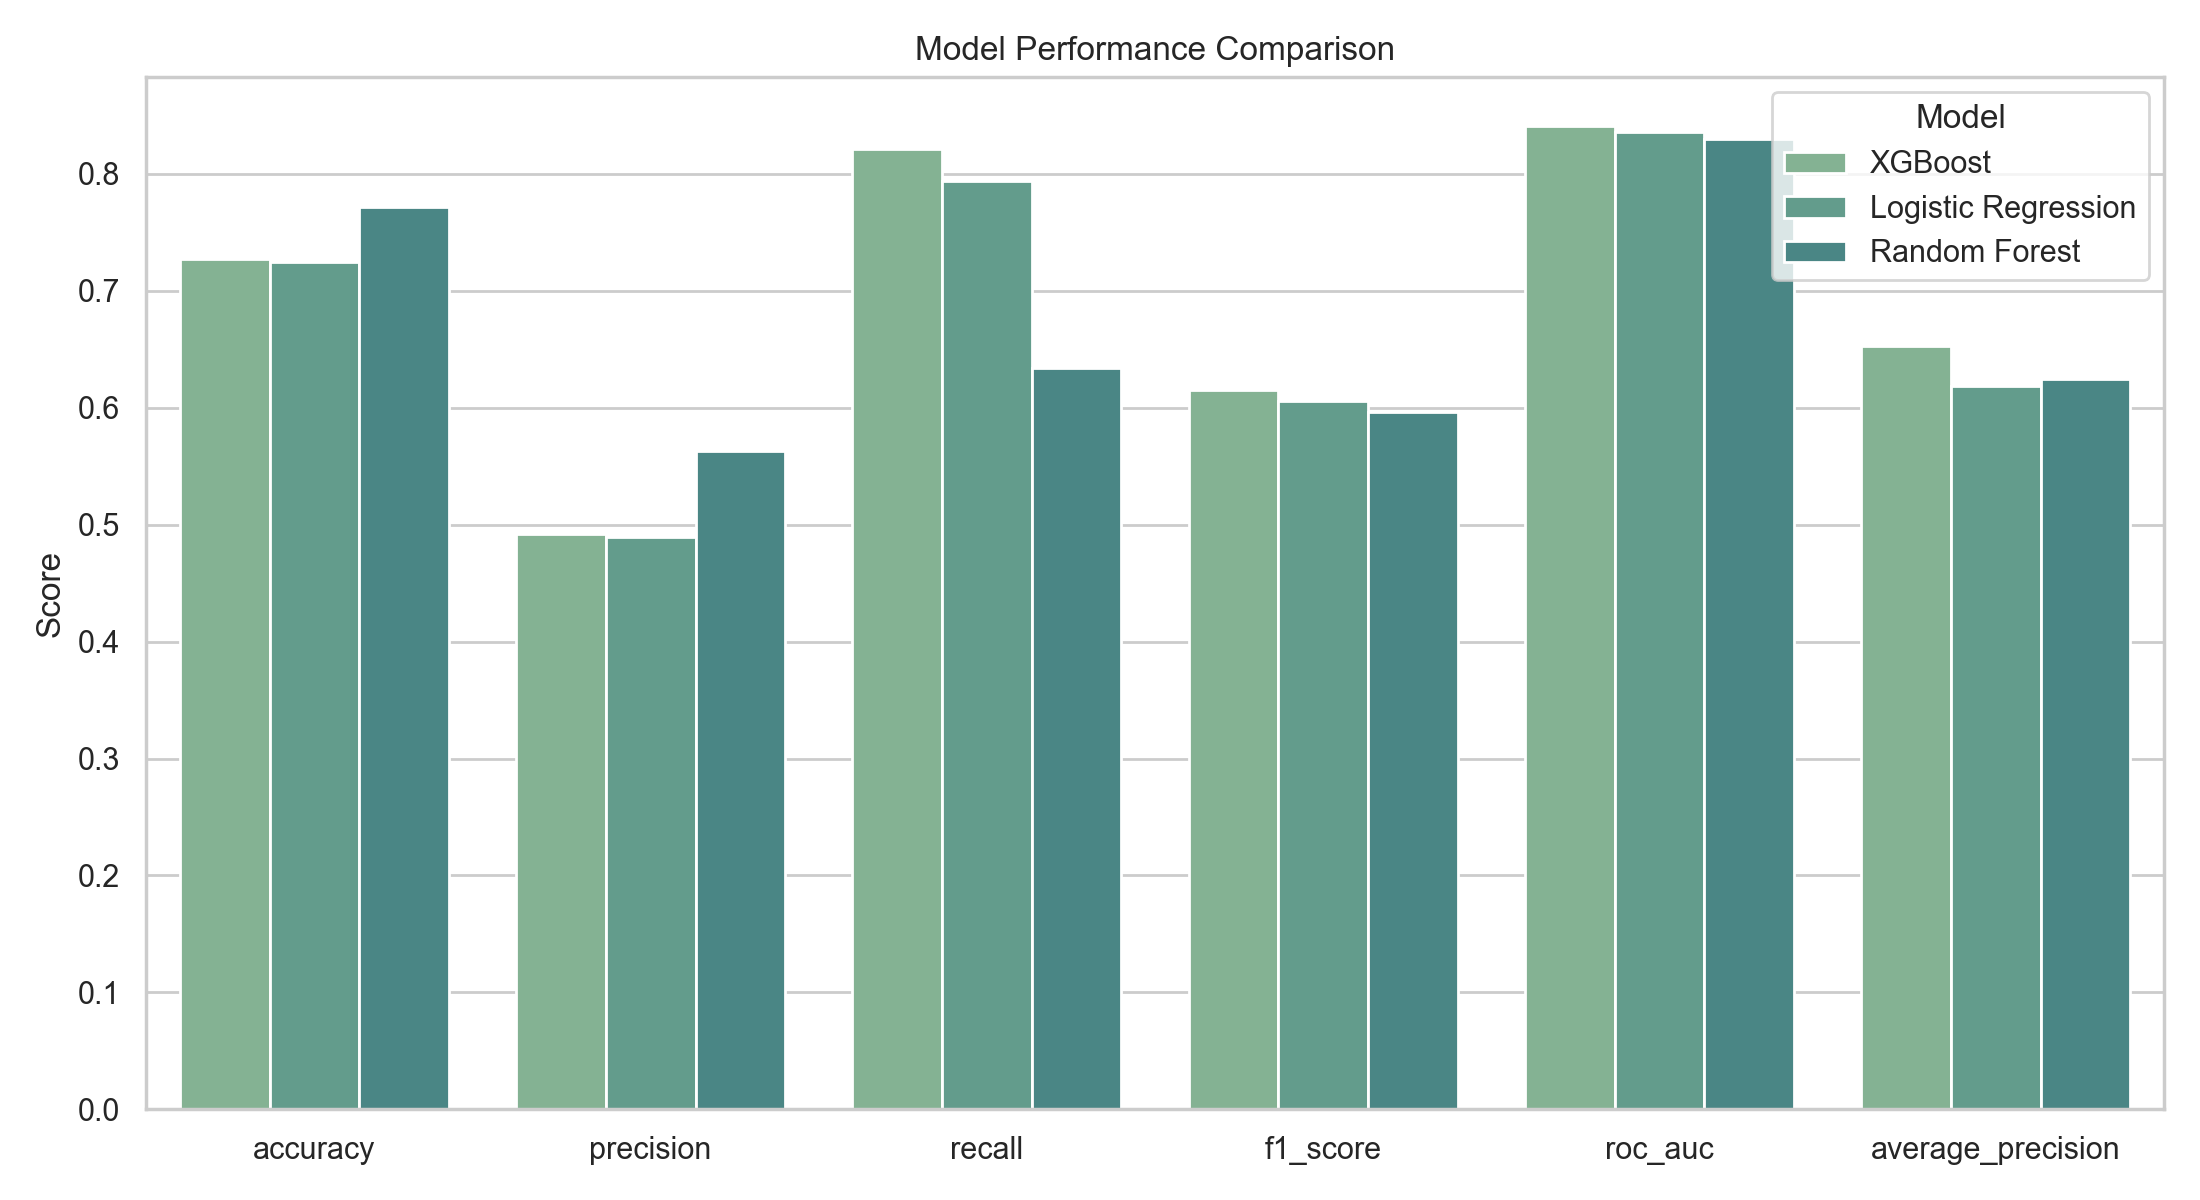

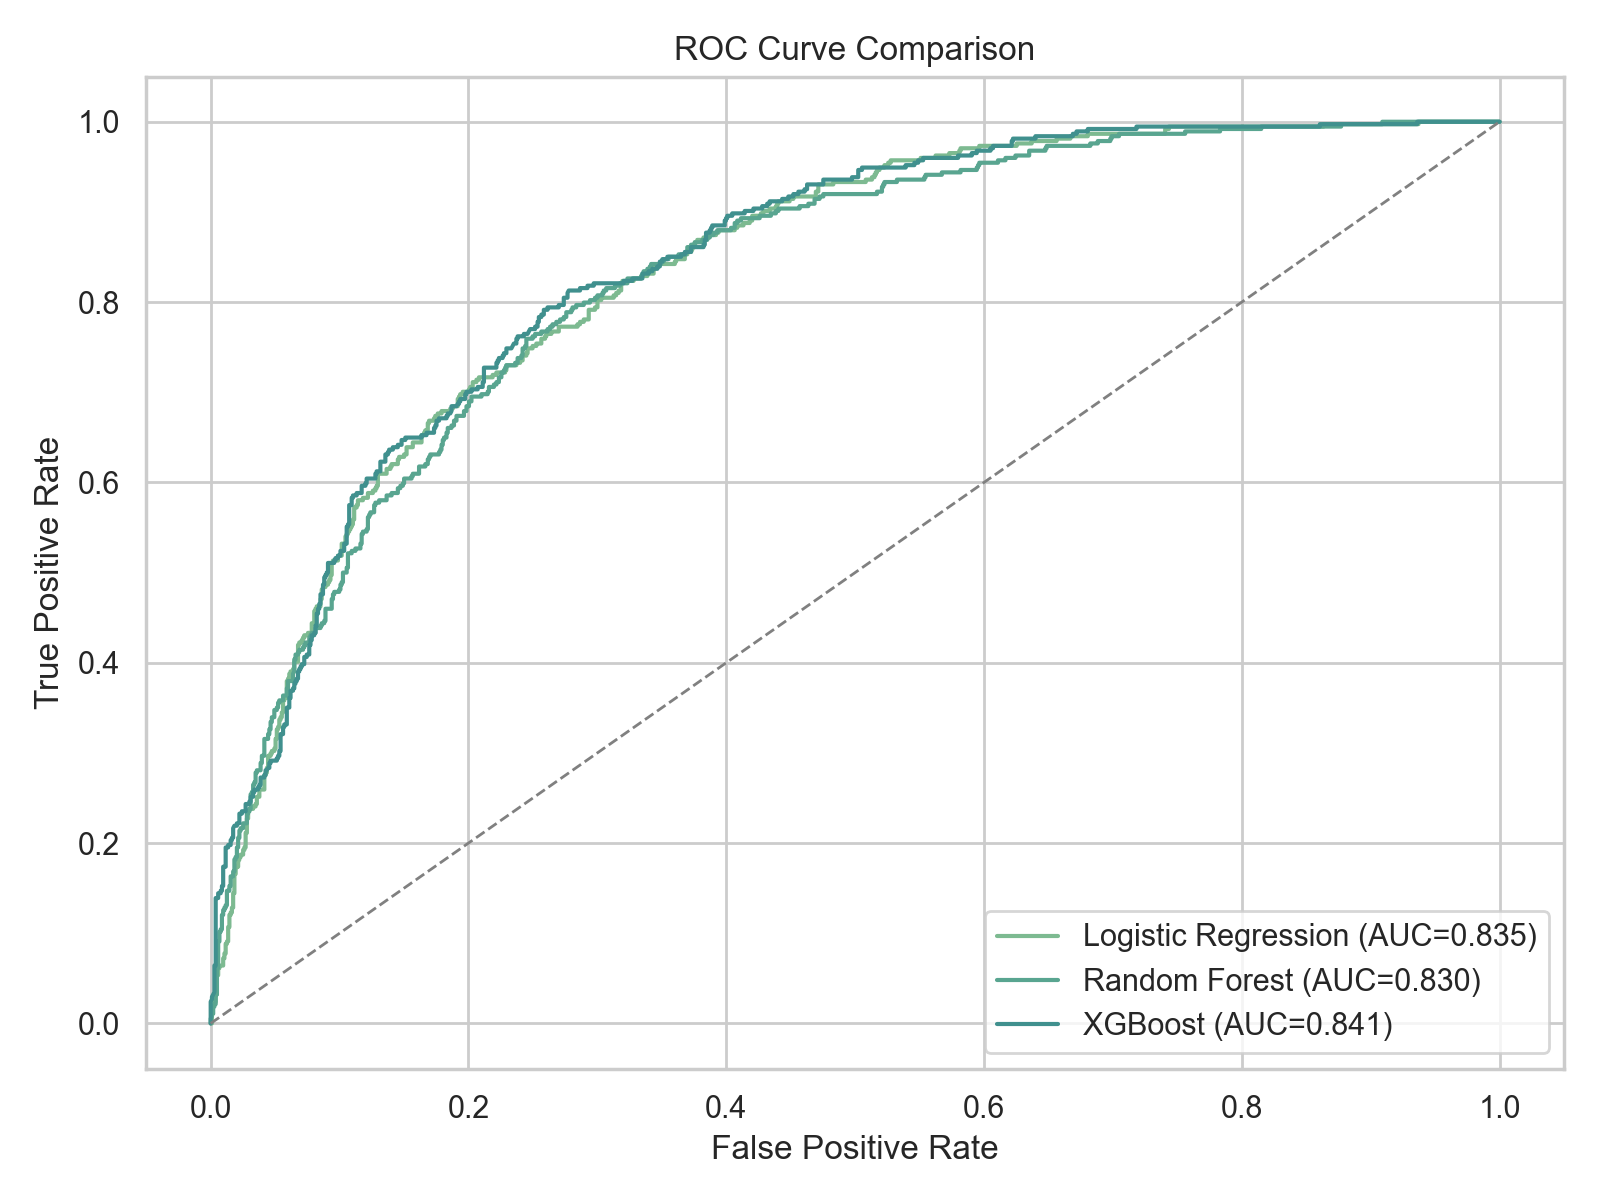

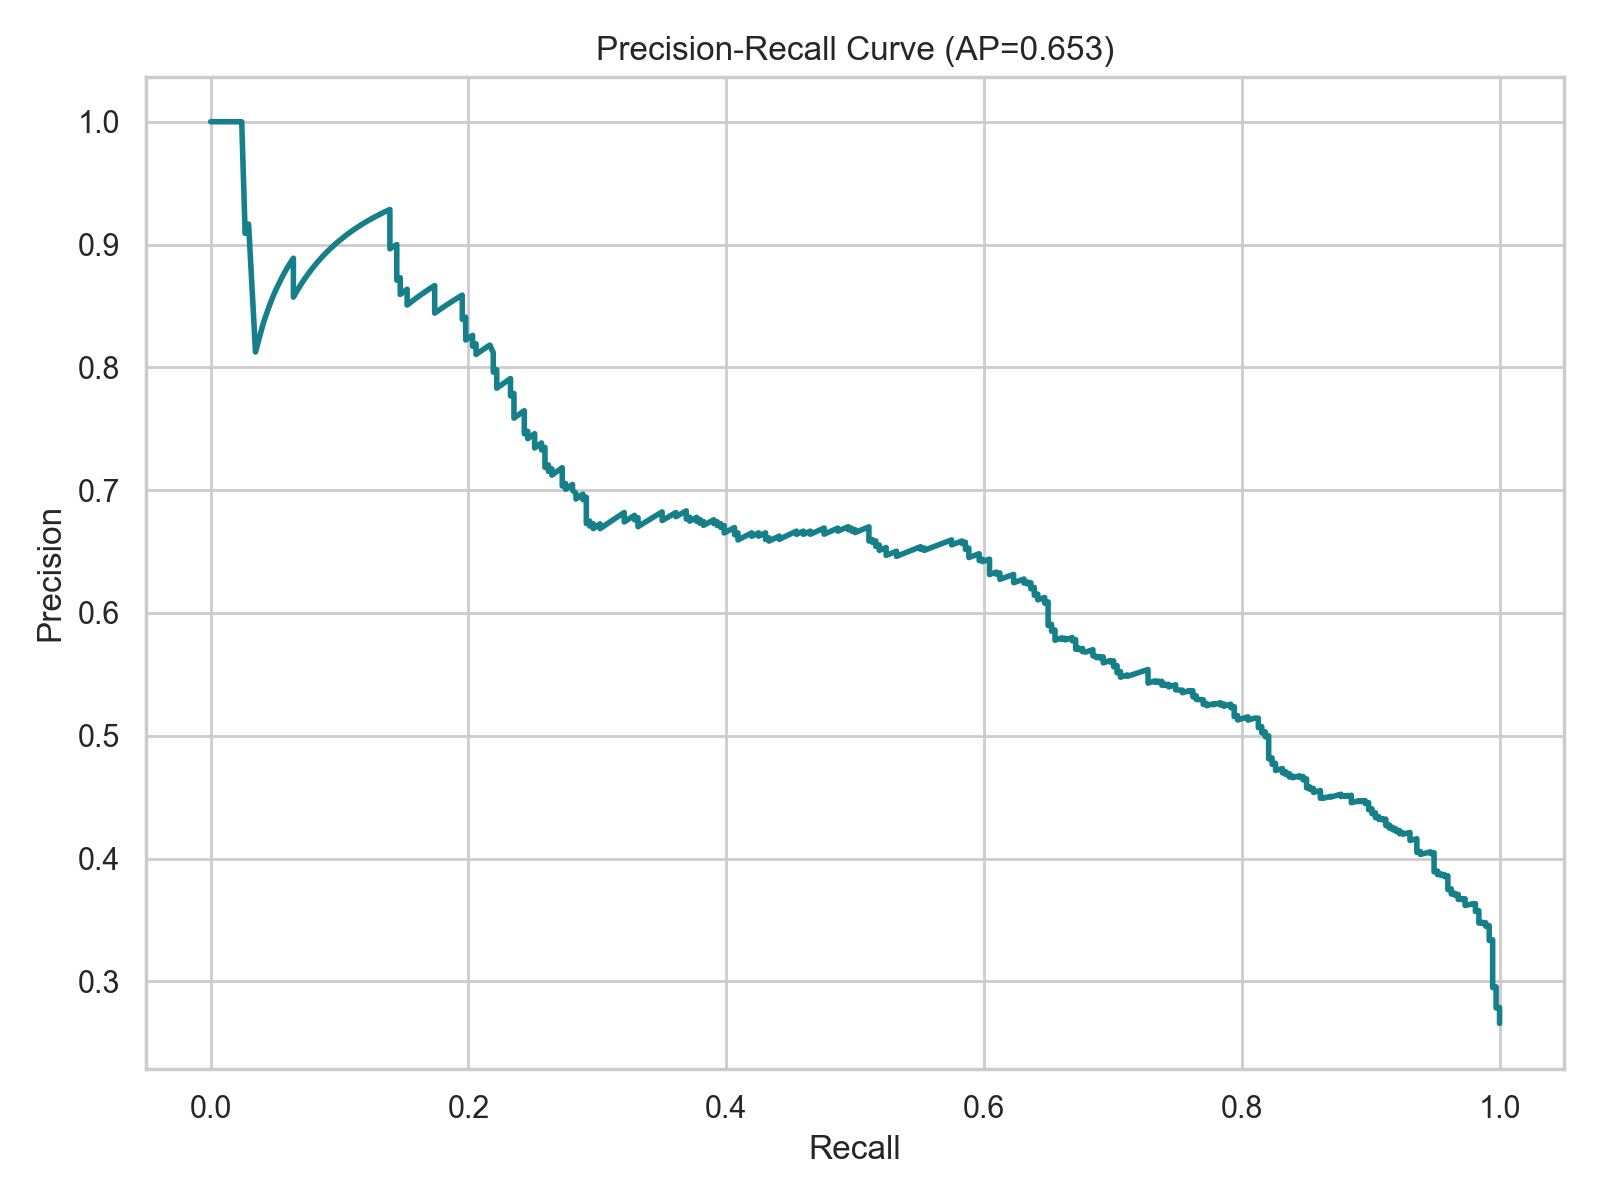

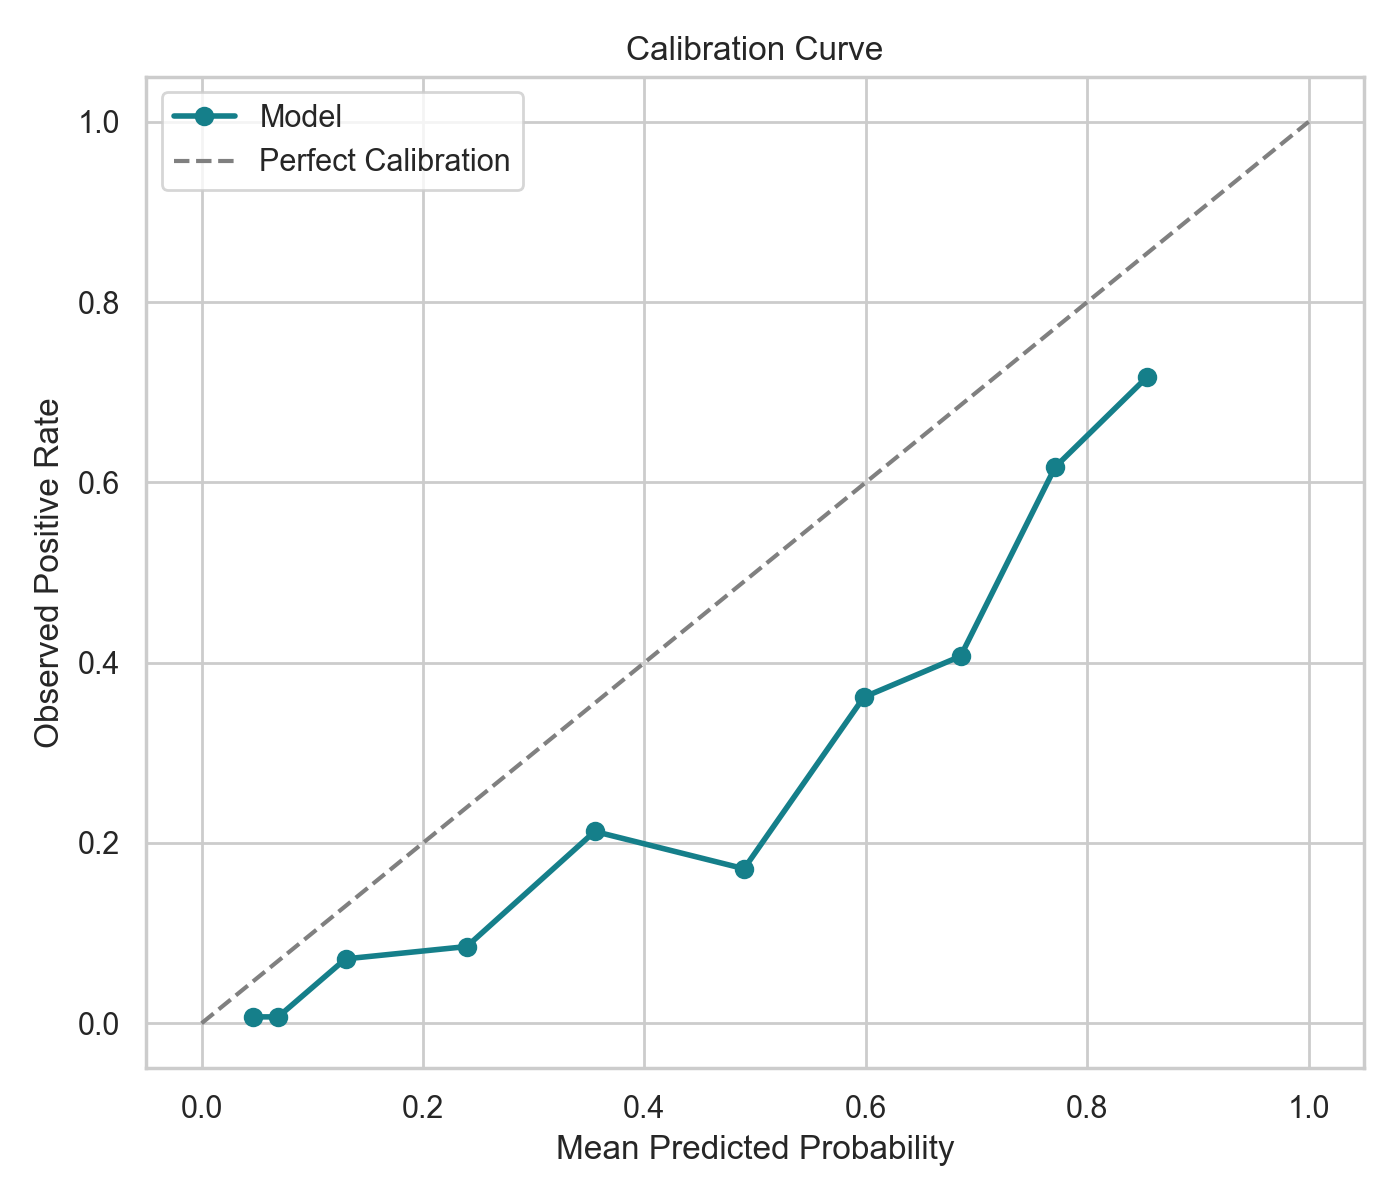

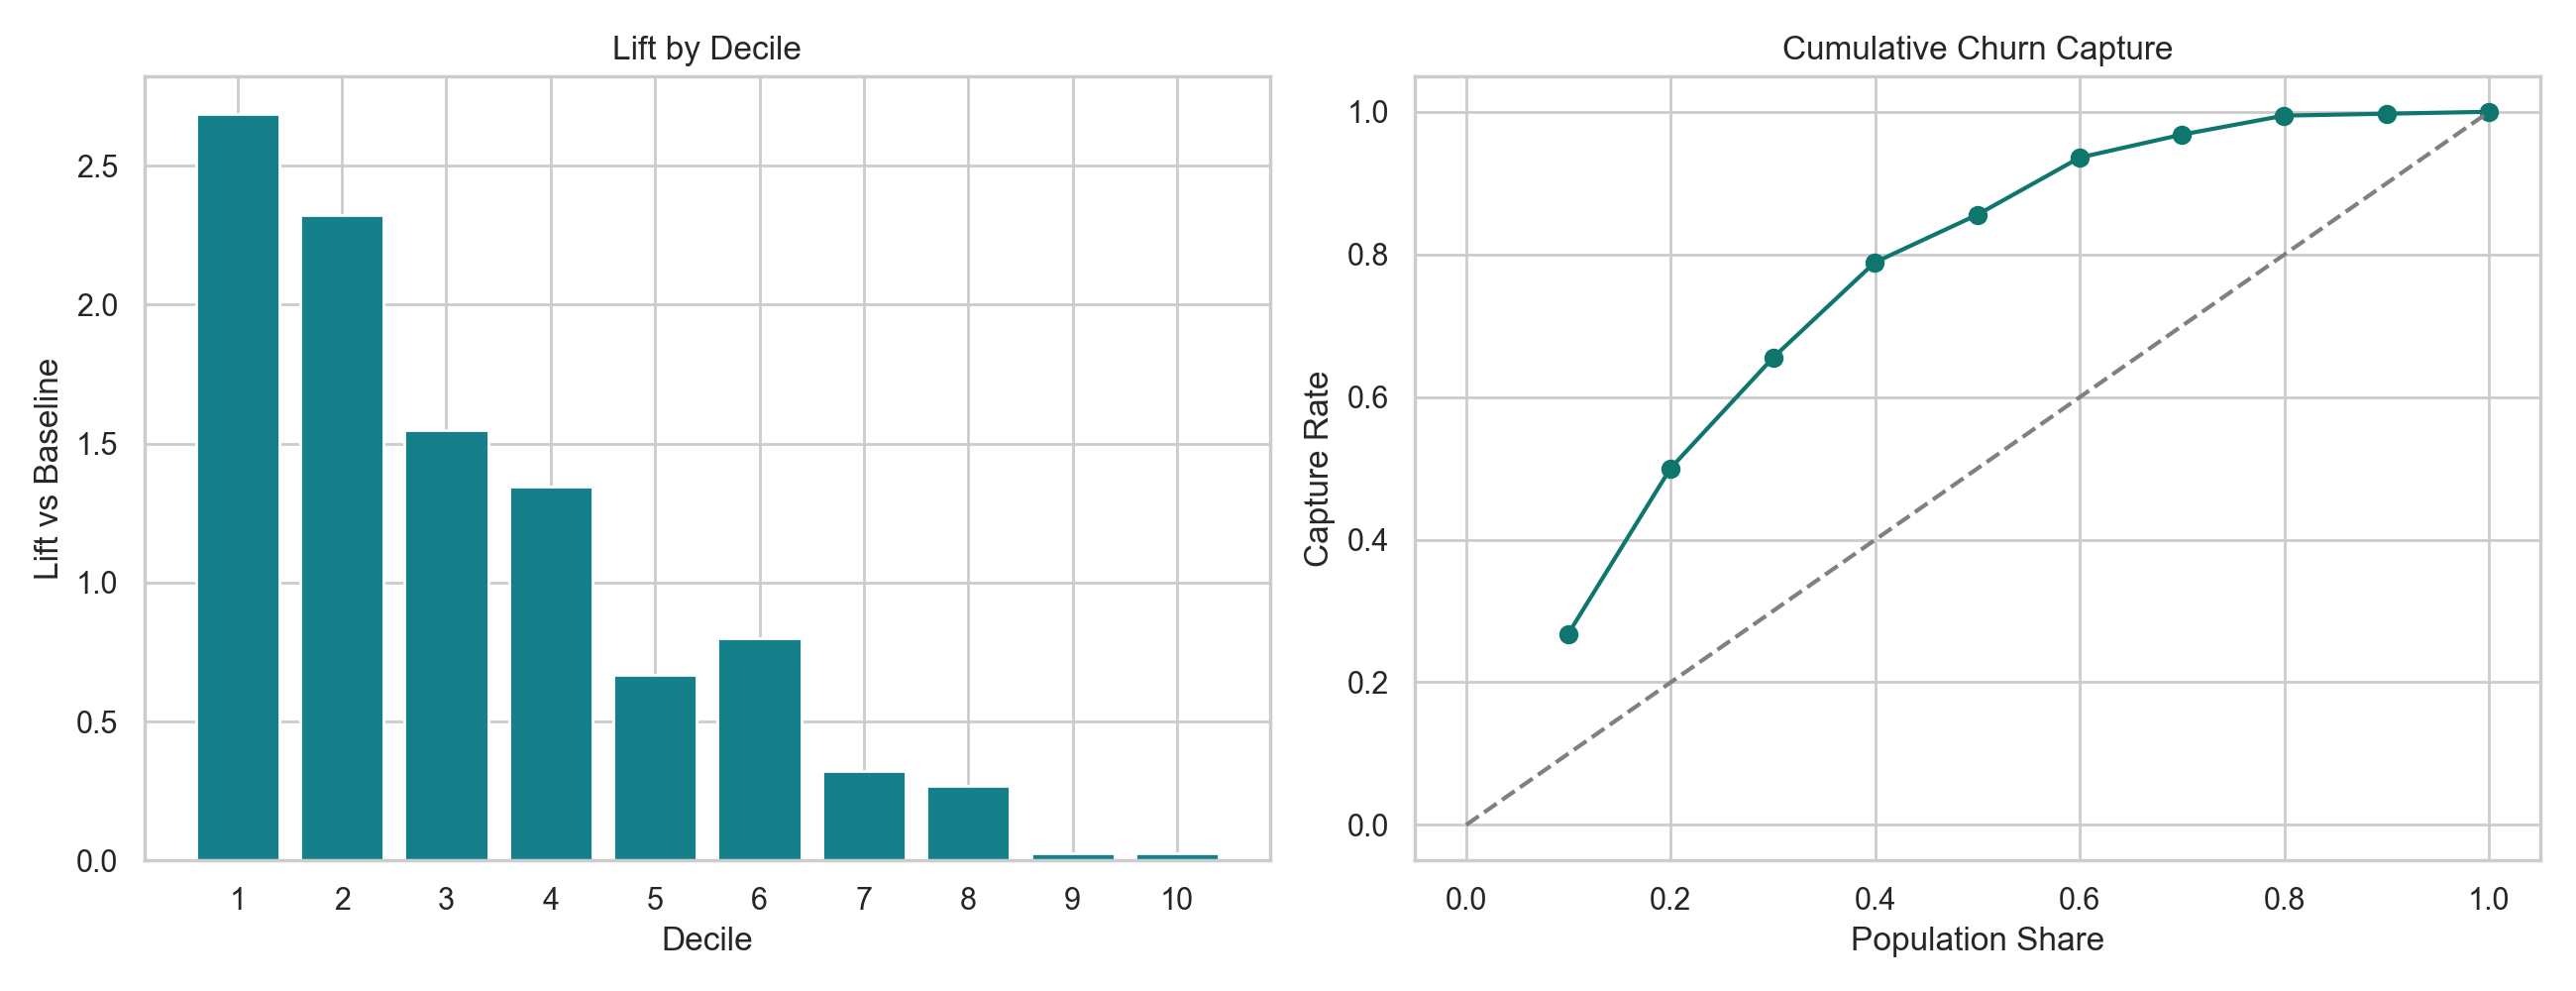

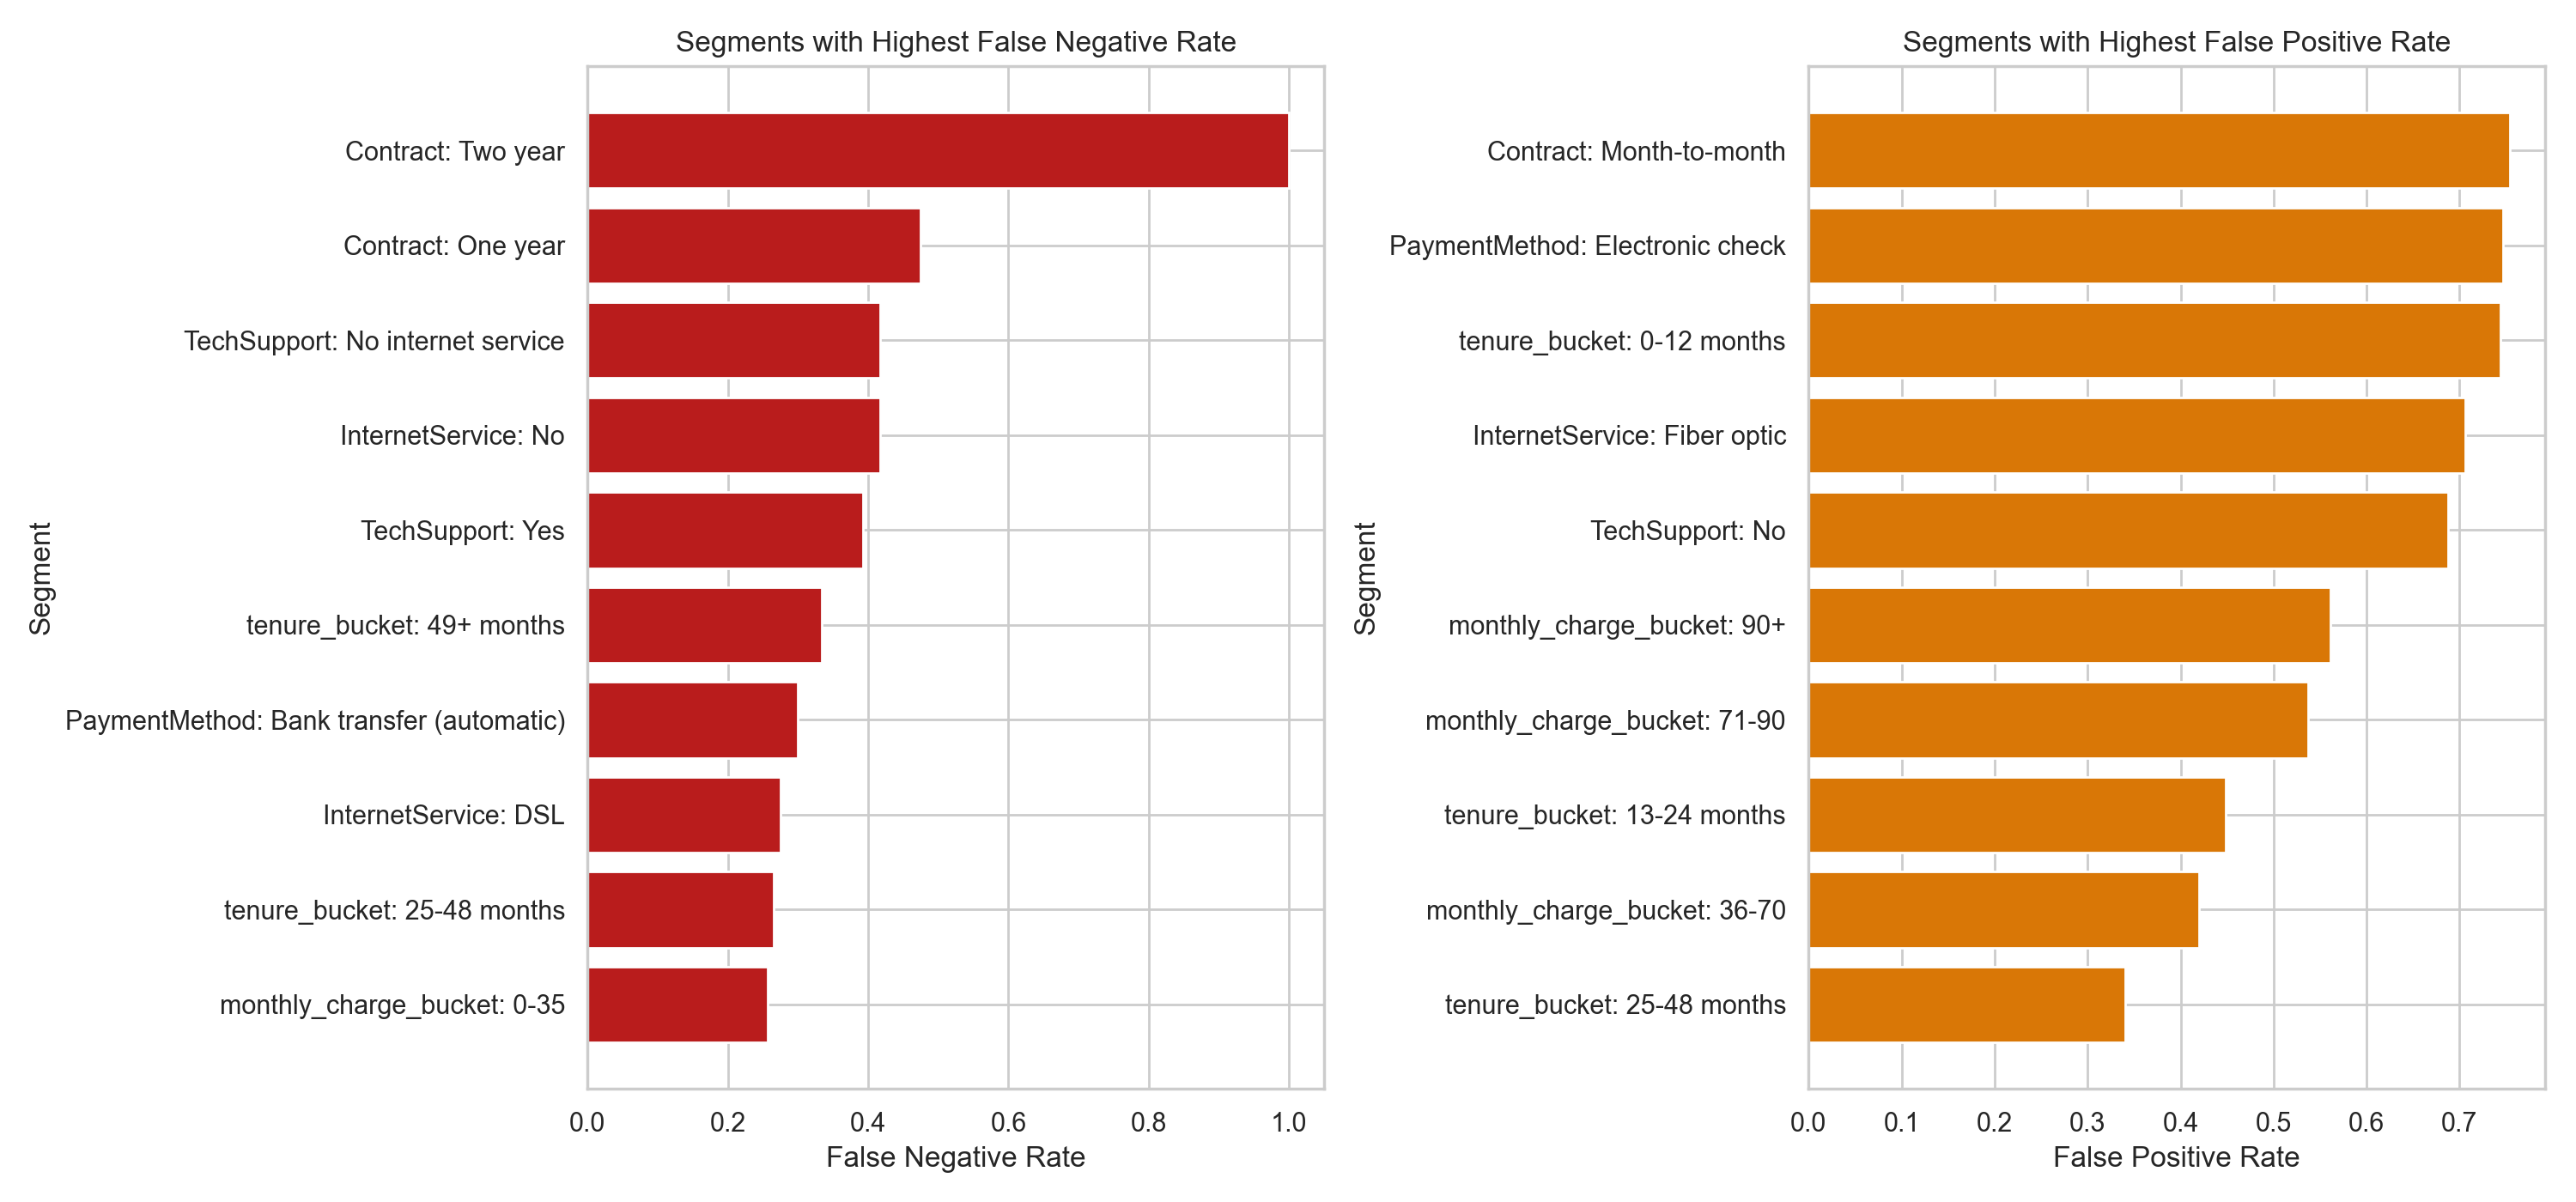

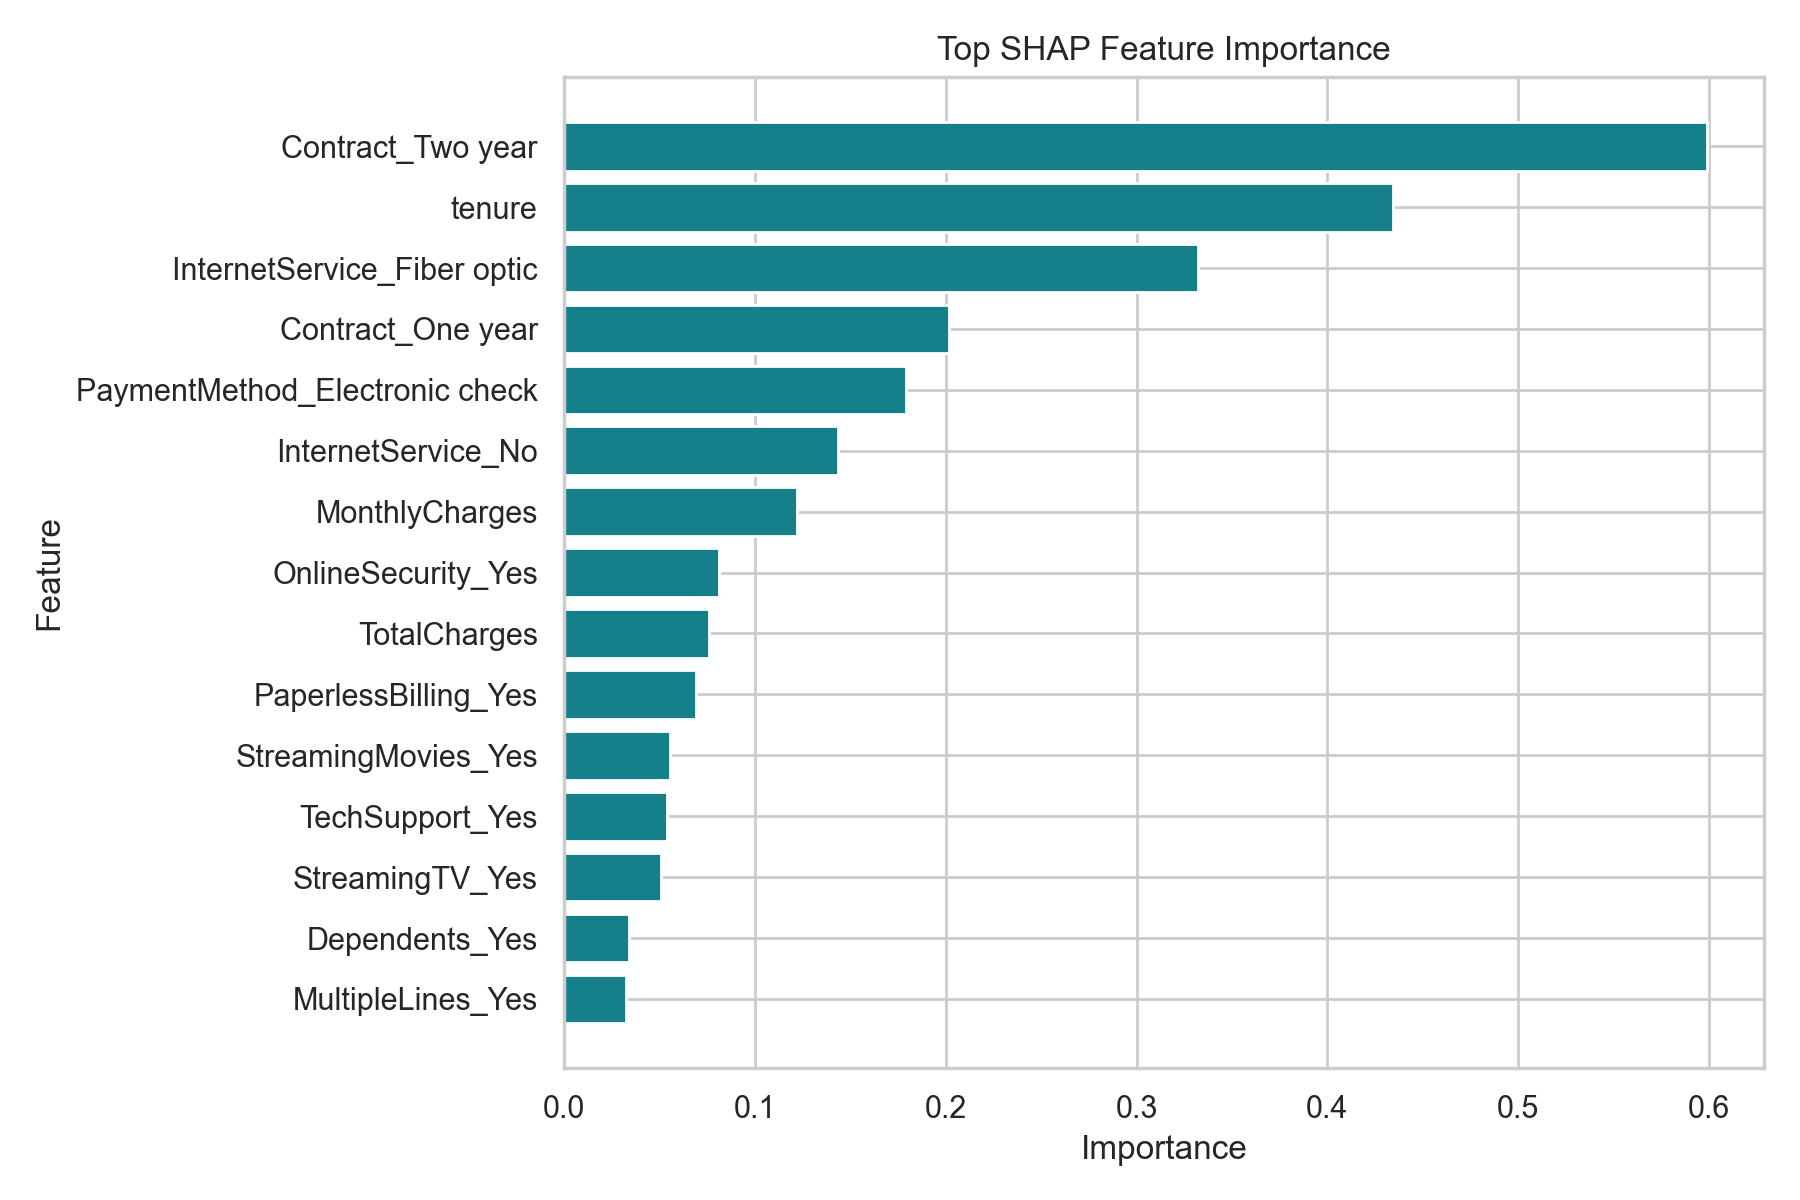

In [9]:
from IPython.display import Image, display

for filename in [
    'model_comparison.png',
    'roc_curve_comparison.png',
    'precision_recall_curve.png',
    'calibration_curve.png',
    'lift_analysis.png',
    'error_analysis.png',
    'shap_feature_importance.png',
]:
    display(Image(filename=str(FIGURES_DIR / filename), width=900))

## Interpretation

- XGBoost is the deployed model because it offers the best ROC-AUC and the strongest churn recall among the evaluated candidates.
- The threshold analysis shows a business trade-off between recall and precision, with `0.40` chosen for stronger churn capture.
- Lift analysis confirms the model is useful for ranked retention campaigns because the top decile captures a large share of churners.
- Calibration and error analysis expose segments where the model over- or under-flags risk.
- SHAP importance confirms that contract length, tenure, internet service, pricing, and billing behavior drive churn predictions.